In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

# **Upload Dataset**

In [ ]:
import numpy as np

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving bike+sharing+dataset.zip to bike+sharing+dataset (2).zip


**UNZIP THE FILE**

In [ ]:
import zipfile
import os

zip_file ="bike+sharing+dataset.zip"  # change name if needed

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("data")

os.listdir("data")


['day.csv', 'hour.csv', 'Readme.txt']

***Load Dataset***

In [ ]:
import pandas as pd

df = pd.read_csv("data/day.csv")
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
df.shape

(731, 16)

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


The dataset contains multiple features that describe environmental conditions, temporal information, and user behavior related to bike rentals.

##instant: Unique index for each record. It simply identifies each row in the dataset.
##dteday: Date of the observation. It represents the specific day on which the data was recorded.
* season: Indicates the season of the year.
 * (1 = Spring, 2 = Summer, 3 = Fall, 4 = Winter)
* yr: Year of the data.
(0 = 2011, 1 = 2012)
* mnth: Month of the year (1 to 12).
* holiday: Indicates whether the day is a holiday or not.
(1 = Holiday, 0 = Not a holiday)
* weekday: Day of the week (0 to 6).
* workingday: Indicates if the day is a working day.
(1 = Working day, 0 = Weekend or holiday)
* weathersit: Describes the weather condition:
1 = Clear or partly cloudy
2 = Mist or cloudy
3 = Light rain or snow
4 = Heavy rain or extreme weather
* temp: Normalized temperature value. It represents the actual temperature scaled to a smaller range.
* atemp: “Feels like” temperature. This considers human perception of temperature.
* hum: Humidity level (normalized).
* windspeed: Wind speed (normalized).
* casual: Number of rentals by casual (non-registered) users.
* registered: Number of rentals by registered users.
* cnt: Total number of bike rentals (casual + registered).
This is the target variable that we aim to predict.**bold text**

In [ ]:
# Step 5: Check missing values
df.isnull().sum()


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [ ]:
# Step 6: Convert date column
df['dteday'] = pd.to_datetime(df['dteday'])
# inference: date column ready for time analysis

**Basic Data Analysis Through graphs**

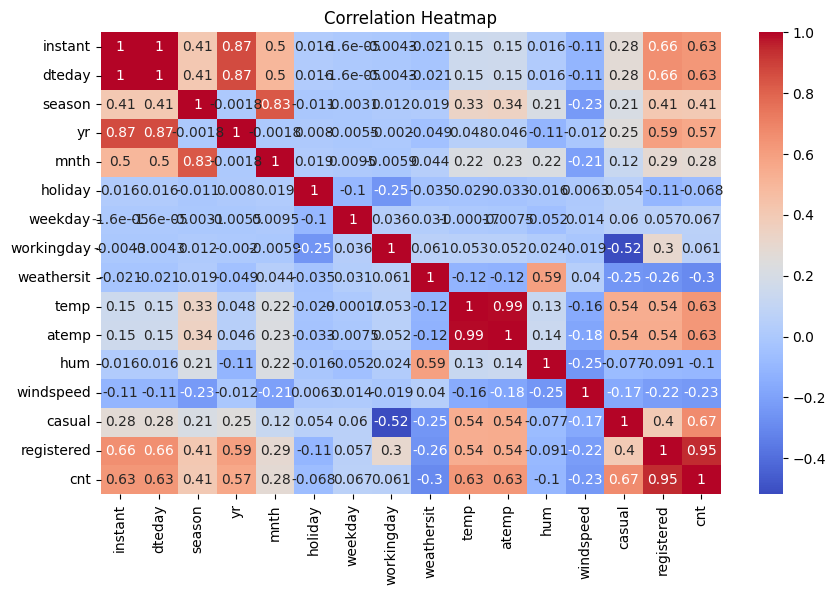

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
# inference:
# temp has positive relation with rentals
# humidity has negative relation
# some features strongly affect demand

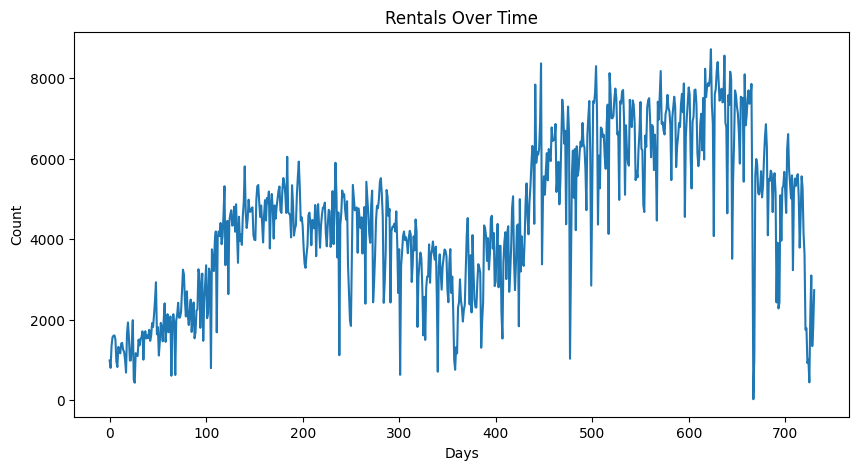

In [ ]:
# Step 8: Rentals over time
plt.figure(figsize=(10,5))
plt.plot(df['cnt'])
plt.title("Rentals Over Time")
plt.xlabel("Days")
plt.ylabel("Count")
plt.show()
# inference: rentals change over time, shows trend and seasonality

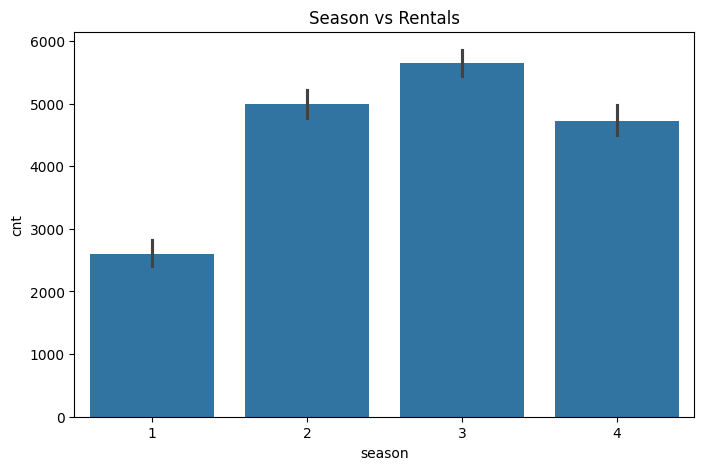

In [ ]:
# Step 9: Season vs rentals
plt.figure(figsize=(8,5))
sns.barplot(x='season', y='cnt', data=df)
plt.title("Season vs Rentals")
plt.show()
# inference: higher rentals in summer and fall

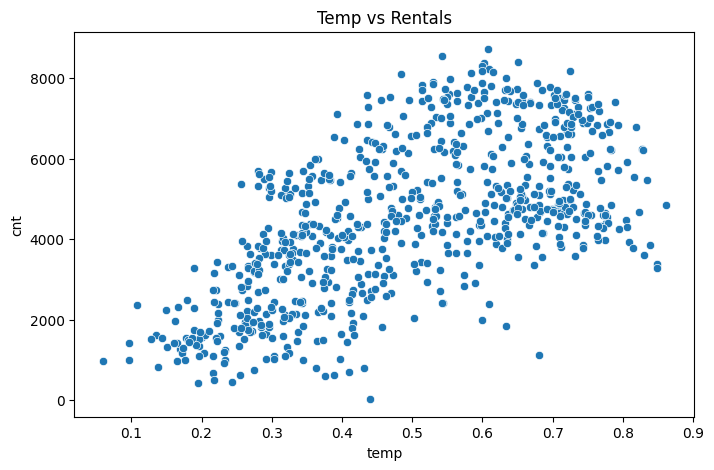

In [ ]:
# Step 10: Temperature vs rentals
plt.figure(figsize=(8,5))
sns.scatterplot(x='temp', y='cnt', data=df)
plt.title("Temp vs Rentals")
plt.show()
# inference: as temperature increases, rentals increase

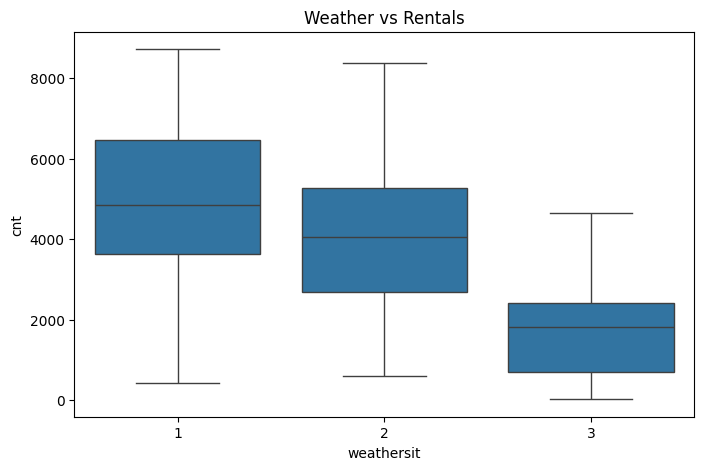

In [ ]:
# Step 11: Weather vs rentals
plt.figure(figsize=(8,5))
sns.boxplot(x='weathersit', y='cnt', data=df)
plt.title("Weather vs Rentals")
plt.show()
# inference: bad weather reduces rentals


In [ ]:
# Step 12: Basic stats
print("Average:", df['cnt'].mean())
print("Max:", df['cnt'].max())
print("Min:", df['cnt'].min())
# inference: shows overall demand range and average usage

Average: 4504.3488372093025
Max: 8714
Min: 22


The exploratory data analysis of the bike sharing dataset provides clear insights into the factors influencing bike rental demand.

From the analysis, we observe that the dataset is clean, with no missing values, making it suitable for further machine learning tasks. The statistical summary shows a good distribution of rental counts, indicating variability in demand across different days.

The correlation analysis reveals that environmental factors play a significant role in determining bike rentals. In particular, temperature shows a strong positive relationship with demand, meaning that as the temperature increases, more people tend to rent bikes. On the other hand, humidity and adverse weather conditions negatively impact rentals, indicating that people prefer not to use bikes in uncomfortable or harsh weather.

The time series visualization highlights clear trends and seasonal patterns in the data, suggesting that demand is not constant but varies over time. This indicates that temporal features such as season and date will be important for predictive modeling.

Further analysis of categorical features shows that seasons significantly influence demand, with higher rentals observed during summer and fall compared to other seasons. Similarly, weather conditions have a noticeable impact, where clear weather leads to higher usage, while poor weather conditions reduce demand.

Overall, these insights confirm that bike rental demand is strongly dependent on a combination of weather conditions, seasonal trends, and environmental factors. This makes the dataset highly suitable for building predictive models.

 In the next phase of the project, we will perform feature engineering and apply machine learning models such as LSTM to accurately predict bike rental demand. **bold text**

📊 Dataset Overview (Hourly Data)

This dataset contains bike rental data recorded on an hourly basis between 2011 and 2012.

Each row represents the number of bike rentals in a specific hour
Total records are around 17,000, making it more detailed than daily data
It includes features like weather, season, time, and user types
🎯 Objective
To analyze patterns in bike rental demand
To understand how time, weather, and season affect usage **bold text**

In [ ]:
df = pd.read_csv("data/hour.csv")

In [ ]:
df.head()
# inference: shows hourly data with many features

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [ ]:
# Step 2: Check shape
df.shape
# inference: around 17,000 rows -> confirms hourly dataset

(17379, 17)

In [ ]:
# Step 3: Basic info
df.info()
# inference: shows data types and confirms no missing values

df.describe()
# inference: shows distribution of rentals and other features

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [ ]:
# Step 4: Convert date column
df['dteday'] = pd.to_datetime(df['dteday'])
# inference: helps in time-based analysis



  Important Features
* hr: Hour of the day (0–23)
* season: Season (1 = Spring, 2 = Summer, 3 = Fall, 4 = Winter)
* workingday: Whether it is a working day
* weathersit: Weather condition
* temp: Temperature
* hum: Humidity
* windspeed: Wind speed
* cnt: Total rentals (target variable)




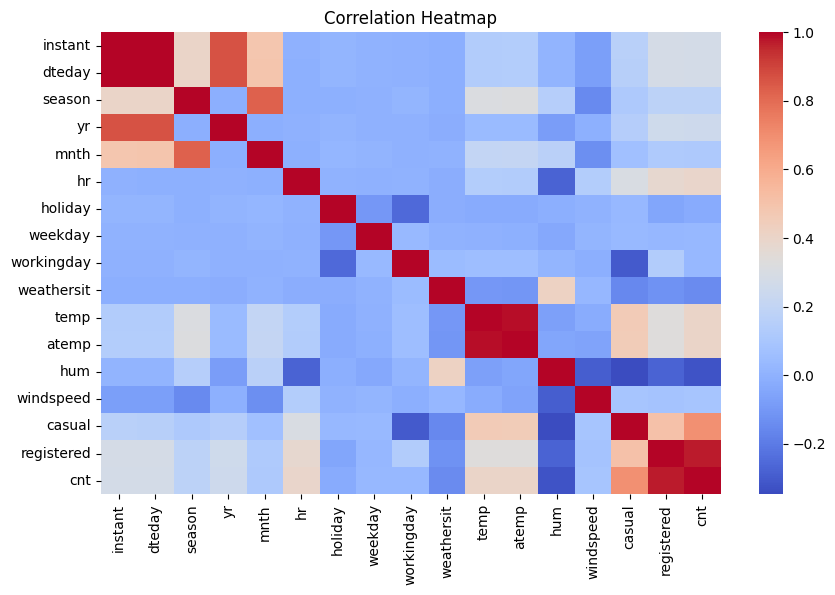

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
# inference:
# temperature positively affects rentals
# humidity negatively affects rentals

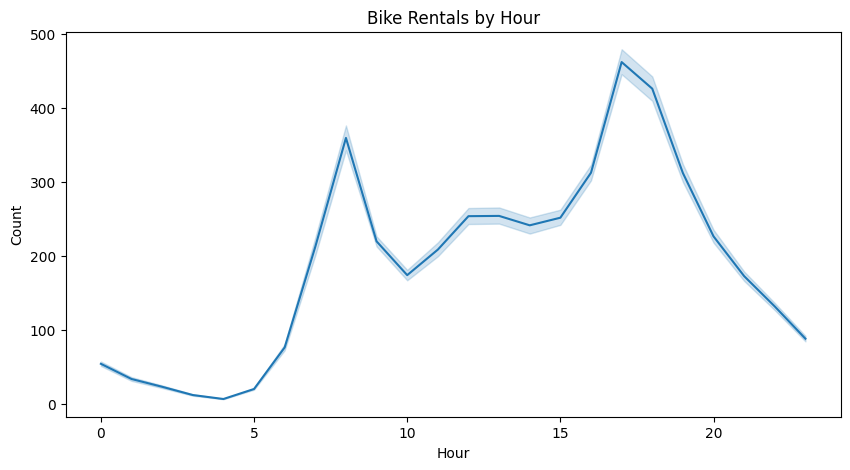

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(x='hr', y='cnt', data=df)
plt.title("Bike Rentals by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()
# inference:
# peak rentals in morning and evening
# shows office commuting pattern

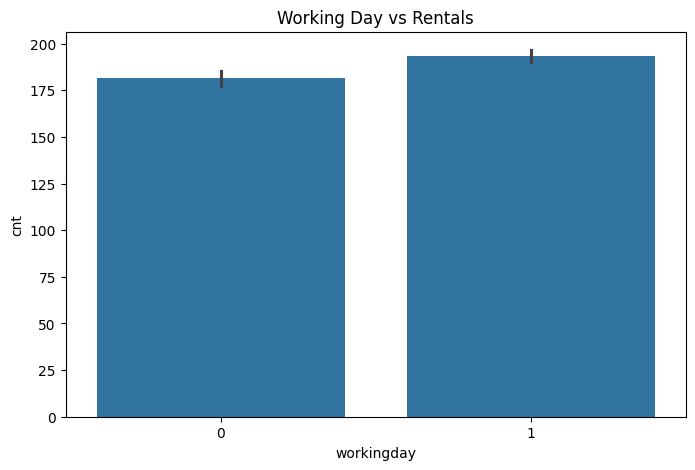

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='workingday', y='cnt', data=df)
plt.title("Working Day vs Rentals")
plt.show()
# inference:
# higher rentals on working days

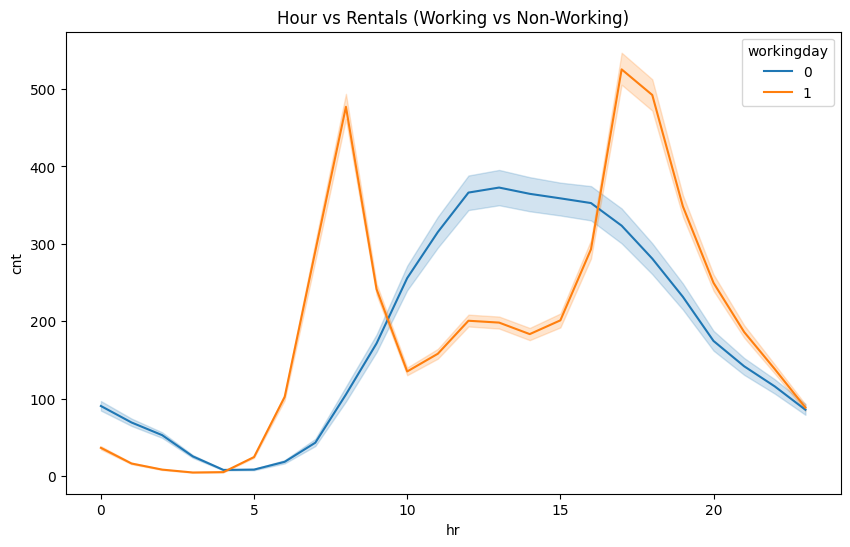

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(x='hr', y='cnt', hue='workingday', data=df)
plt.title("Hour vs Rentals (Working vs Non-Working)")
plt.show()
# inference:
# working days show clear peak hours
# non-working days are more uniform

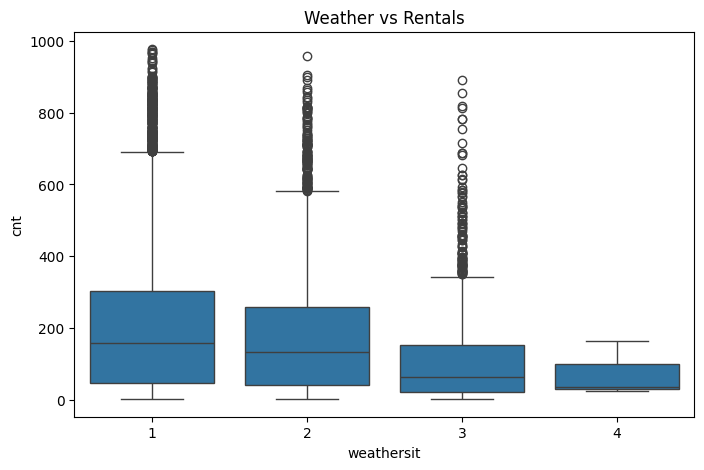

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='weathersit', y='cnt', data=df)
plt.title("Weather vs Rentals")
plt.show()
# inference:
# bad weather reduces rentals significantly

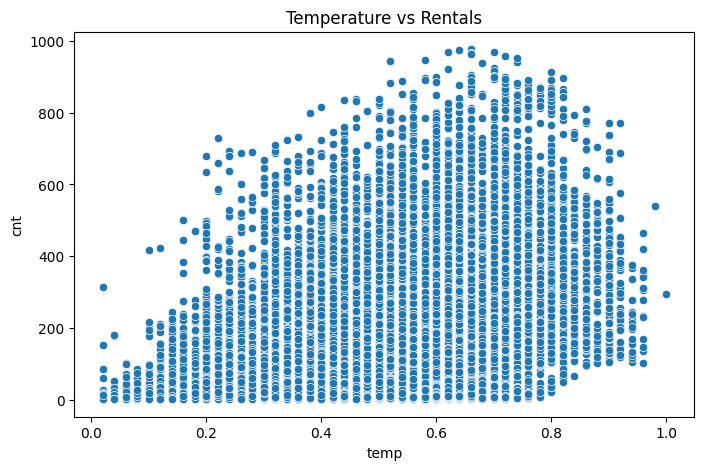

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='temp', y='cnt', data=df)
plt.title("Temperature vs Rentals")
plt.show()
# inference:
# rentals increase as temperature increases

Conclusion

From the analysis of the hourly bike rental dataset, we can observe several important patterns.

The dataset is large and detailed, containing around 17,000 records, which allows for deeper insights compared to daily data. There are no missing values, making it reliable for analysis and modeling.

The hourly analysis shows clear usage patterns, where bike rentals peak during morning and evening hours. This indicates that most users use bikes for commuting purposes, especially during office hours.

Working days show higher rental demand compared to non-working days, further confirming that bikes are commonly used for daily travel.

Weather and environmental factors also play a significant role. Higher temperatures lead to increased rentals, while bad weather conditions such as rain or snow reduce bike usage.

Overall, the dataset demonstrates that bike rental demand is strongly influenced by time, weather, and working conditions. These insights will help in building accurate predictive models in the next phase. **bold text**